# The Species-Area Relationship of Amphibians in the Southern Appalachians

This notebook reproduces the species–area relationship (SAR) analysis from:

> **Stout, J.B., Jessee, L.D., & McMeen, J.N. (2025).** Nested and island models for determining the species-area relationship of southern Appalachian amphibians. *Journal of North American Herpetology*, 2025(1), 1–7. [https://doi.org/10.17161/jnah.v2025i1.21557](https://doi.org/10.17161/jnah.v2025i1.21557)

The paper establishes two SAR models for amphibians across the southern Appalachian ecoregion:

- **Nested model** (Appendix 1, n = 7): seven concentric areas from a single wetland pond (0.0018 km²) to all of southern Appalachia (178,758 km²).
- **Island model** (Appendix 2, n = 26): 26 individual sites (parks, counties, and other well-surveyed areas) within the study region.

Both models use the classical log-linear approach: species richness and area are log₁₀-transformed, and a linear regression is fitted to produce the power model S = CA^z.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Load and Explore the Data

The two datasets correspond to the paper's Appendix 1 (nested) and Appendix 2 (island).

In [2]:
nested = pd.read_csv("data/nested.csv")
island = pd.read_csv("data/island.csv")

print("=== Nested Model (n = 7) ===")
display(nested)
print("\n=== Island Model (n = 26) ===")
display(island)

=== Nested Model (n = 7) ===


,Locality,Area,AmphibianSpecies,FrogSpecies,SalamanderSpecies
0,Area 1,0.0018,10,7,3
1,Area 2,9.3000,22,10,12
2,Area 3,1114.0000,38,13,25
3,Area 4,4137.0000,44,13,31
4,Area 5,37438.0000,69,18,52
5,Area 6,101271.0000,88,20,68
6,Area 7,178758.0000,98,22,76



=== Island Model (n = 26) ===


,Locality,Area,AmphibianSpecies,FrogSpecies,SalamanderSpecies
0,John's Bog (Blue Ridge),0.0081,10,1,9
1,Henderson Bog,0.1010,12,5,7
2,UT Arboretum,1.0100,16,9,7
3,"Sweet's Farm, Highland Co. VA",1.5700,13,5,8
4,Cantonment Area WV,3.7800,17,7,10
5,Briery Mountain WV,4.2300,14,4,10
6,Pringle Tract WV,8.5400,11,4,7
7,Harper's Ferry NHP WV,9.6500,16,6,10
8,New River SP NC,13.4500,18,7,11
9,Elk Knob SP NC,17.9000,17,4,13


## Regression Method

The paper fits log₁₀(S) = log₁₀(C) + z · log₁₀(A) for each taxonomic group, recovering the power model parameters as C = 10^(intercept) and z = slope. We reproduce this using `scipy.stats.linregress` to obtain the slope, intercept, R², and p-value for each regression.

In [3]:
def fit_log_linear(df, area_col="Area", species_col="AmphibianSpecies"):
    """Fit log-linear OLS regression and return a dict of results."""
    log_a = np.log10(df[area_col].values)
    log_s = np.log10(df[species_col].values)
    result = stats.linregress(log_a, log_s)
    z = result.slope
    log_c = result.intercept
    c = 10 ** log_c
    r2 = result.rvalue ** 2
    p = result.pvalue
    return {
        "z": z, "C": c, "R2": r2, "p": p,
        "log_a": log_a, "log_s": log_s,
        "intercept": log_c, "slope": z,
    }

groups = ["AmphibianSpecies", "FrogSpecies", "SalamanderSpecies"]
labels = ["Amphibians", "Frogs", "Salamanders"]

## Nested Model Regressions

Seven concentric areas ranging from a wetland pond at Steele Creek Park to the entirety of southern Appalachia as defined in the study.

In [4]:
nested_fits = {}
print("Nested Model — Log-Linear Regression Results\n")
print(f"{'Group':<15} {'C':>8} {'z':>8} {'R²':>8} {'p':>12}")
print("-" * 55)

for label, col in zip(labels, groups):
    fit = fit_log_linear(nested, species_col=col)
    nested_fits[label] = fit
    print(f"{label:<15} {fit['C']:>8.2f} {fit['z']:>8.4f} {fit['R2']:>8.4f} {fit['p']:>12.2e}")

print("\nPaper reported values:")
print("  Amphibians:  C = 18.87, z = 0.1222, R² = 0.9667")
print("  Frogs:       C =  9.34, z = 0.0598, R² = 0.9279")
print("  Salamanders: C =  8.36, z = 0.1734, R² = 0.9924")

Nested Model — Log-Linear Regression Results

Group                  C        z       R²            p
-------------------------------------------------------
Amphibians         18.87   0.1222   0.9667     6.94e-05
Frogs               9.34   0.0598   0.9279     4.87e-04
Salamanders         8.36   0.1734   0.9924     1.73e-06

Paper reported values:
  Amphibians:  C = 18.87, z = 0.1222, R² = 0.9667
  Frogs:       C =  9.34, z = 0.0598, R² = 0.9279
  Salamanders: C =  8.36, z = 0.1734, R² = 0.9924


### Nested Model — Log-Log Scatter with Regression Lines

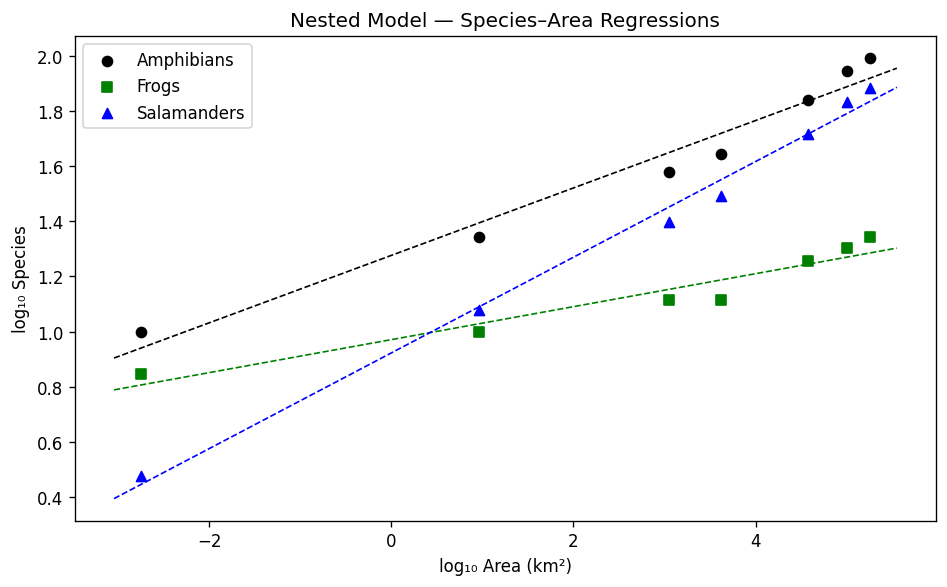

In [5]:
colors = {"Amphibians": "black", "Frogs": "green", "Salamanders": "blue"}
markers = {"Amphibians": "o", "Frogs": "s", "Salamanders": "^"}

fig, ax = plt.subplots(figsize=(8, 5))

for label in labels:
    fit = nested_fits[label]
    ax.scatter(fit["log_a"], fit["log_s"],
               color=colors[label], marker=markers[label], label=label, zorder=5)
    x_line = np.linspace(fit["log_a"].min() - 0.3, fit["log_a"].max() + 0.3, 100)
    y_line = fit["slope"] * x_line + fit["intercept"]
    ax.plot(x_line, y_line, color=colors[label], linestyle="--", linewidth=1)

ax.set_xlabel("log₁₀ Area (km²)")
ax.set_ylabel("log₁₀ Species")
ax.set_title("Nested Model — Species–Area Regressions")
ax.legend()
plt.tight_layout()
plt.show()

## Island Model Regressions

Twenty-six individual sites from published amphibian surveys across the southern Appalachian ecoregion.

In [6]:
island_fits = {}
print("Island Model — Log-Linear Regression Results\n")
print(f"{'Group':<15} {'C':>8} {'z':>8} {'R²':>8} {'p':>12}")
print("-" * 55)

for label, col in zip(labels, groups):
    fit = fit_log_linear(island, species_col=col)
    island_fits[label] = fit
    print(f"{label:<15} {fit['C']:>8.2f} {fit['z']:>8.4f} {fit['R2']:>8.4f} {fit['p']:>12.2e}")

print("\nPaper reported values:")
print("  Amphibians:  C = 13.92, z = 0.108, R² = 0.757")
print("  Frogs:       C =  4.28, z = 0.134, R² = 0.658")
print("  Salamanders: C =  8.95, z = 0.104, R² = 0.564")

Island Model — Log-Linear Regression Results

Group                  C        z       R²            p
-------------------------------------------------------
Amphibians         13.92   0.1079   0.7572     7.70e-09
Frogs               4.28   0.1338   0.6582     4.96e-07
Salamanders         8.95   0.1043   0.5641     9.82e-06

Paper reported values:
  Amphibians:  C = 13.92, z = 0.108, R² = 0.757
  Frogs:       C =  4.28, z = 0.134, R² = 0.658
  Salamanders: C =  8.95, z = 0.104, R² = 0.564


### Island Model — Log-Log Scatter with Regression Lines

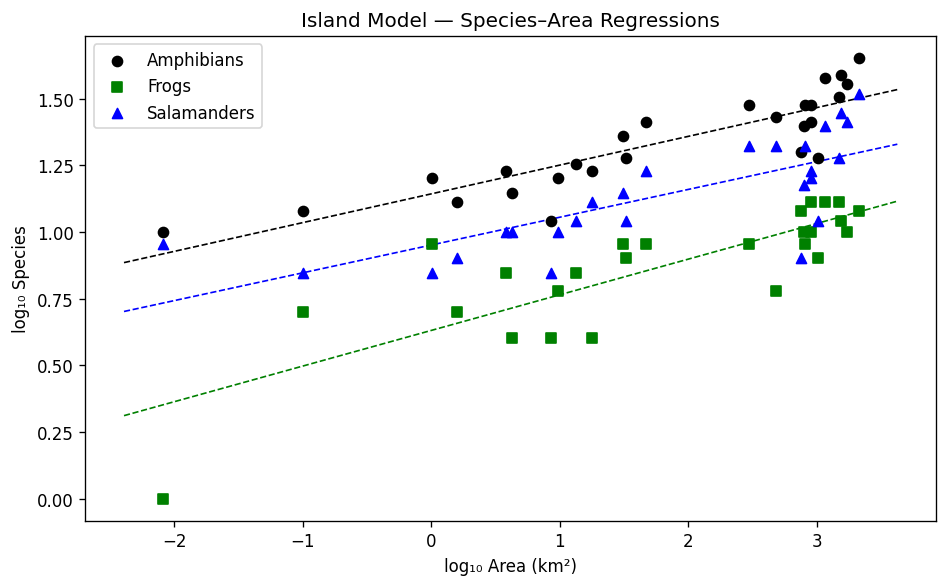

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for label in labels:
    fit = island_fits[label]
    ax.scatter(fit["log_a"], fit["log_s"],
               color=colors[label], marker=markers[label], label=label, zorder=5)
    x_line = np.linspace(fit["log_a"].min() - 0.3, fit["log_a"].max() + 0.3, 100)
    y_line = fit["slope"] * x_line + fit["intercept"]
    ax.plot(x_line, y_line, color=colors[label], linestyle="--", linewidth=1)

ax.set_xlabel("log₁₀ Area (km²)")
ax.set_ylabel("log₁₀ Species")
ax.set_title("Island Model — Species–Area Regressions")
ax.legend()
plt.tight_layout()
plt.show()

## Nested vs. Island Model Comparison

Reproducing the paper's Figure 2: side-by-side comparison of the nested and island regression lines for each taxonomic group.

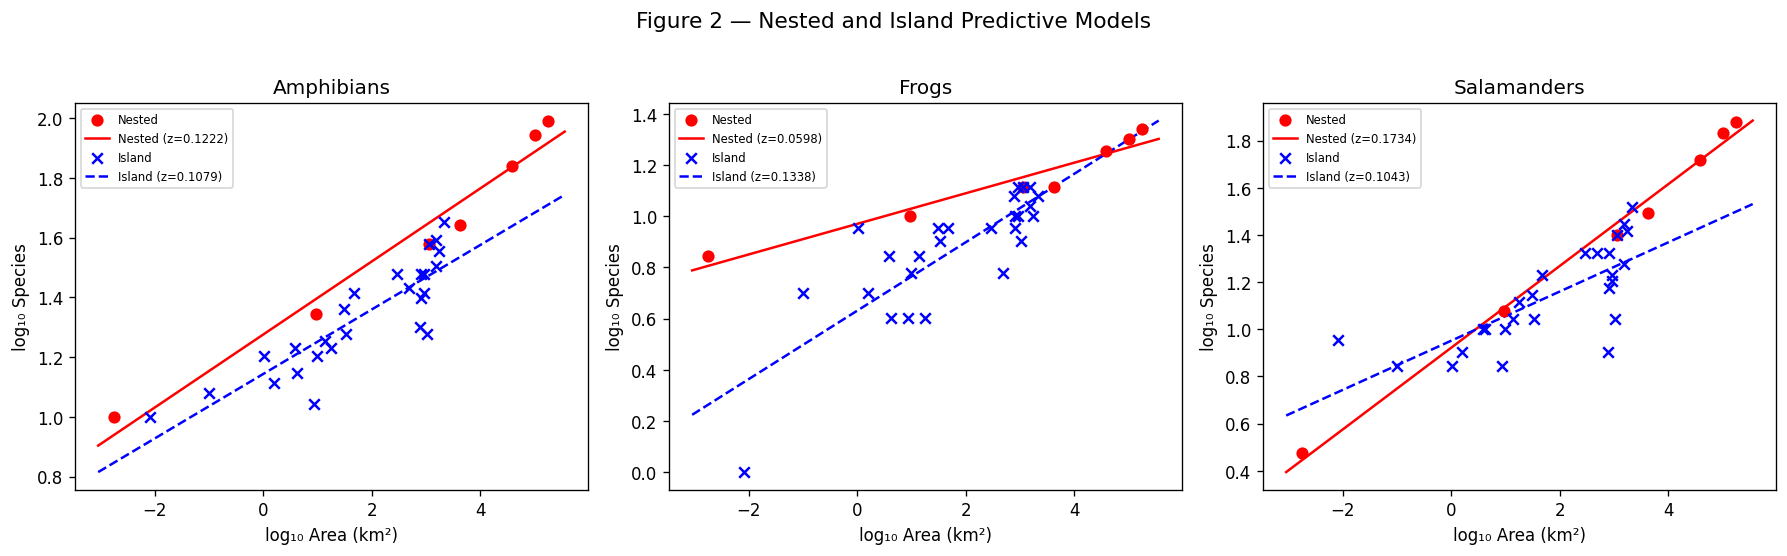

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, label in zip(axes, labels):
    nf = nested_fits[label]
    isf = island_fits[label]

    # shared x range spanning both datasets
    x_min = min(nf["log_a"].min(), isf["log_a"].min()) - 0.3
    x_max = max(nf["log_a"].max(), isf["log_a"].max()) + 0.3
    x_line = np.linspace(x_min, x_max, 200)

    # nested regression line and points
    ax.scatter(nf["log_a"], nf["log_s"], color="red", marker="o", label="Nested", zorder=5, s=40)
    ax.plot(x_line, nf["slope"] * x_line + nf["intercept"],
            color="red", linewidth=1.5, label=f"Nested (z={nf['z']:.4f})")

    # island regression line and points
    ax.scatter(isf["log_a"], isf["log_s"], color="blue", marker="x", label="Island", zorder=5, s=40)
    ax.plot(x_line, isf["slope"] * x_line + isf["intercept"],
            color="blue", linestyle="--", linewidth=1.5, label=f"Island (z={isf['z']:.4f})")

    ax.set_xlabel("log₁₀ Area (km²)")
    ax.set_ylabel("log₁₀ Species")
    ax.set_title(label)
    ax.legend(fontsize=7)

plt.suptitle("Figure 2 — Nested and Island Predictive Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Parameter Comparison Table

In [9]:
rows = []
for label in labels:
    nf = nested_fits[label]
    isf = island_fits[label]
    rows.append({
        "Group": label,
        "Nested C": round(nf["C"], 2),
        "Nested z": round(nf["z"], 4),
        "Nested R²": round(nf["R2"], 4),
        "Island C": round(isf["C"], 2),
        "Island z": round(isf["z"], 4),
        "Island R²": round(isf["R2"], 4),
    })

comparison = pd.DataFrame(rows)
display(comparison)

,Group,Nested C,Nested z,Nested R²,Island C,Island z,Island R²
0,Amphibians,18.87,0.1222,0.9667,13.92,0.1079,0.7572
1,Frogs,9.34,0.0598,0.9279,4.28,0.1338,0.6582
2,Salamanders,8.36,0.1734,0.9924,8.95,0.1043,0.5641


## SAR Curves in Arithmetic Space

Plotting S = CA^z for both models in arithmetic space.

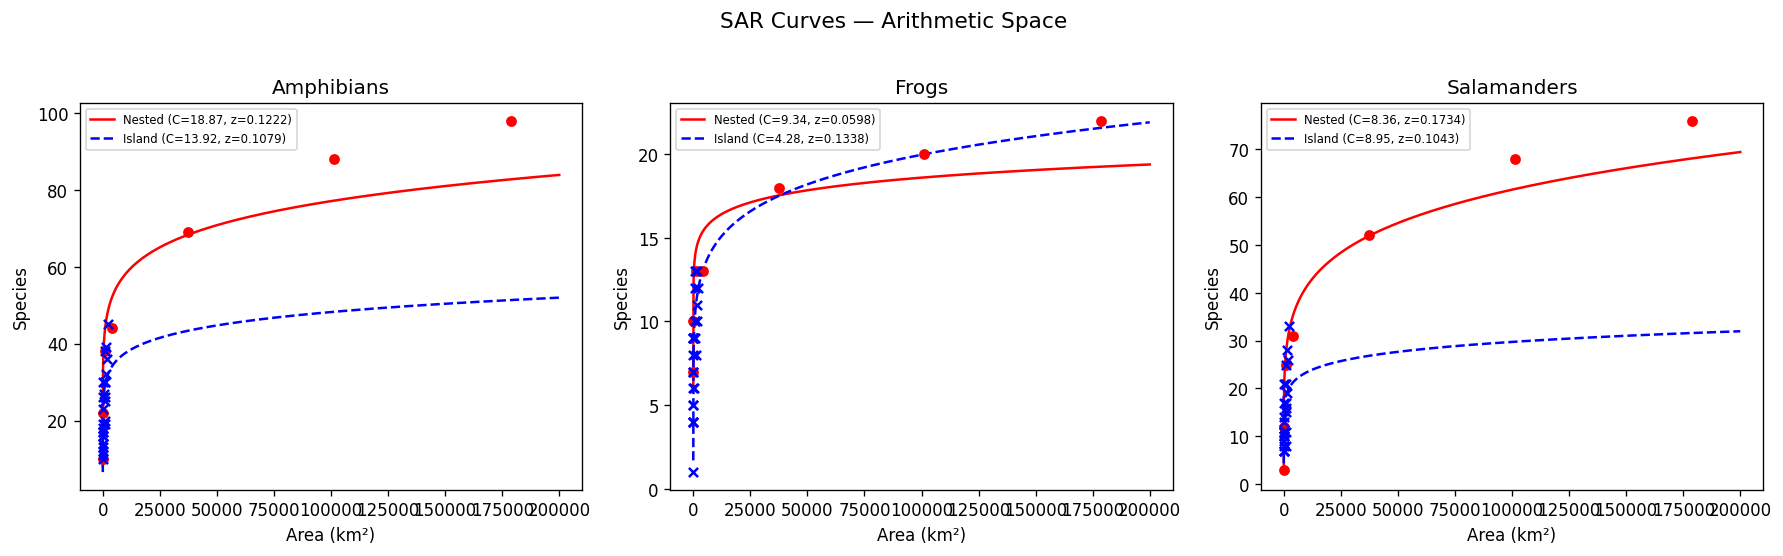

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, label in zip(axes, labels):
    nf = nested_fits[label]
    isf = island_fits[label]

    # generate prediction curves
    areas_arith = np.linspace(0.001, 200000, 2000)
    nested_pred = nf["C"] * areas_arith ** nf["z"]
    island_pred = isf["C"] * areas_arith ** isf["z"]

    ax.plot(areas_arith, nested_pred, color="red", label=f"Nested (C={nf['C']:.2f}, z={nf['z']:.4f})")
    ax.plot(areas_arith, island_pred, color="blue", linestyle="--",
            label=f"Island (C={isf['C']:.2f}, z={isf['z']:.4f})")

    # overlay observed data
    ax.scatter(nested["Area"], nested[groups[labels.index(label)]],
               color="red", marker="o", zorder=5, s=30)
    ax.scatter(island["Area"], island[groups[labels.index(label)]],
               color="blue", marker="x", zorder=5, s=30)

    ax.set_xlabel("Area (km²)")
    ax.set_ylabel("Species")
    ax.set_title(label)
    ax.legend(fontsize=7)

plt.suptitle("SAR Curves — Arithmetic Space", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Predictive Estimates

The paper notes that an average of the two models should provide a reasonable estimate of amphibian diversity at most localities. The UT Arboretum (1.01 km²) provides a compelling test: its reported 16 amphibians falls between the nested C (18.87) and island C (13.92), supporting the interpretation that C reflects a real ecological value.

Let's generate predictions at several reference areas.

In [11]:
test_areas = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]

print(f"{'Area (km²)':>12}  {'Nested Amp':>10}  {'Island Amp':>10}  {'Average':>8}")
print("-" * 50)

for a in test_areas:
    n_pred = nested_fits["Amphibians"]["C"] * a ** nested_fits["Amphibians"]["z"]
    i_pred = island_fits["Amphibians"]["C"] * a ** island_fits["Amphibians"]["z"]
    avg = (n_pred + i_pred) / 2
    print(f"{a:>12,.1f}  {n_pred:>10.1f}  {i_pred:>10.1f}  {avg:>8.1f}")

  Area (km²)  Nested Amp  Island Amp   Average
--------------------------------------------------
         1.0        18.9        13.9      16.4
        10.0        25.0        17.8      21.4
       100.0        33.1        22.9      28.0
     1,000.0        43.9        29.3      36.6
    10,000.0        58.2        37.6      47.9
   100,000.0        77.1        48.2      62.6


## Summary

This notebook reproduces the log-linear OLS analysis from Stout, Jessee & McMeen (2025), covering both the nested and island SAR models for southern Appalachian amphibians.

Key findings from the original publication:

- **Land area is an accurate predictor** of amphibian species richness across the study area.
- The **nested model** produces stronger R² values (amphibians 0.97, salamanders 0.99, frogs 0.93) due to its concentric sampling design, which eliminates between-site habitat variability.
- The **island model** produces lower but still significant R² values (amphibians 0.76, salamanders 0.56, frogs 0.66), reflecting the natural variation among independent sites.
- Both models follow **similar trajectories** (Figure 2), suggesting the species–area curves reflect a genuine ecological pattern.
- The nested model **over-predicts** relative to the island model, likely an artifact of underreported diversity at individual sites — increased sampling should narrow this gap.
- An **average of the two models** is recommended as a reasonable estimate of amphibian diversity at most localities within the study area.

The power model parameters (S = CA^z) are:

| Group | Nested C | Nested z | Island C | Island z |
|---|---|---|---|---|
| Amphibians | 18.87 | 0.1222 | 13.92 | 0.1079 |
| Frogs | 9.34 | 0.0598 | 4.28 | 0.1338 |
| Salamanders | 8.36 | 0.1734 | 8.95 | 0.1043 |

The updated analysis using the `sars` library, which refits these models via nonlinear least squares, is available in [`analysis_updates.ipynb`](analysis_updates.ipynb).